PART1:Load the Dataset

In [2]:
#1
import pandas as pd
from sklearn.datasets import load_iris

In [3]:
#2
iris_data = load_iris(as_frame=True)
df= iris_data.frame #iris_data içinden .frame (tablo) yu df e attık
print(df.head())



   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [4]:
#3
print(df.columns.tolist())

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'target']


In [5]:
#4 - 5
print(iris_data.feature_names)
print(iris_data.target_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


In [6]:
#6
print(df.shape)

(150, 5)


PART2:Understand the Dataset Using Pandas

In [7]:
#7
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [8]:
#8
df.describe

<bound method NDFrame.describe of      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
3                  4.6               3.1                1.5               0.2   
4                  5.0               3.6                1.4               0.2   
..                 ...               ...                ...               ...   
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0                5.1               1

In [9]:
#9
df.isnull()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
145,False,False,False,False,False
146,False,False,False,False,False
147,False,False,False,False,False
148,False,False,False,False,False


In [10]:
#10
class_count= df['target'].value_counts()
print(class_count)


target
0    50
1    50
2    50
Name: count, dtype: int64


In [11]:
#11
#dataset balanced because when we look at value_count(), there are 50 samples for each three classes


In [12]:
#12
#dataset is clean because there is no missing value (df.isnull() == false)
#according to the descriptive statistics 'sepal length' has the highest values overall while 'petal width' has the lowest.

PART3:Prepare Labels for Better Understanding

In [13]:
#13
class_mapping = {
    0: iris_data.target_names[0], # 'setosa'
    1: iris_data.target_names[1], # 'versicolor'
    2: iris_data.target_names[2]  # 'virginica'
}
df['class_name'] = df['target'].map(class_mapping)


In [14]:
#14
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target class_name  
0       0     setosa  
1       0     setosa  
2       0     setosa  
3       0     setosa  
4       0     setosa  


In [15]:
#15
#Using class names makes visualizations much easier to read and interpret. It allows the viewer to immediately understand which flower species they are looking at, without needing to map abstract numbers like 0, 1, or 2 back to their original categories.

PART4: Visualize the Dataset

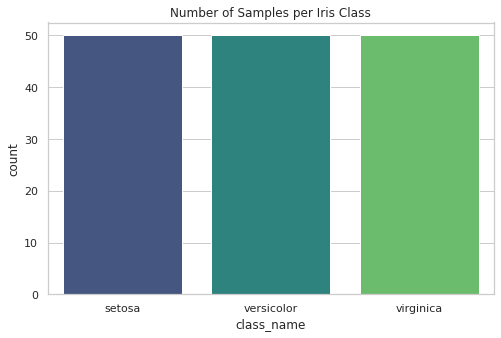

In [16]:
#16
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))#tuval
sns.countplot(data=df, x='class_name', hue='class_name', palette='viridis', legend=False)
plt.title("Number of Samples per Iris Class")
plt.show()

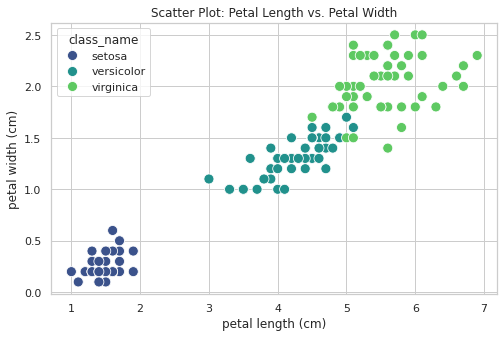

In [17]:
#17
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='petal length (cm)', y='petal width (cm)', hue='class_name', palette='viridis', s=100)
plt.title("Scatter Plot: Petal Length vs. Petal Width")
plt.show()

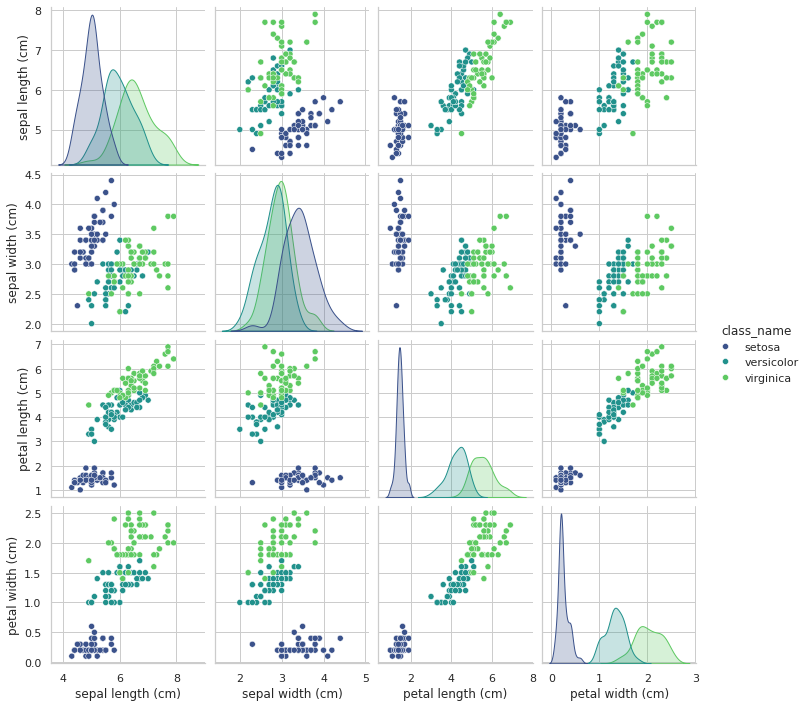

In [18]:
#18
sns.pairplot(df.drop('target', axis=1), hue='class_name', palette='viridis')
plt.show()

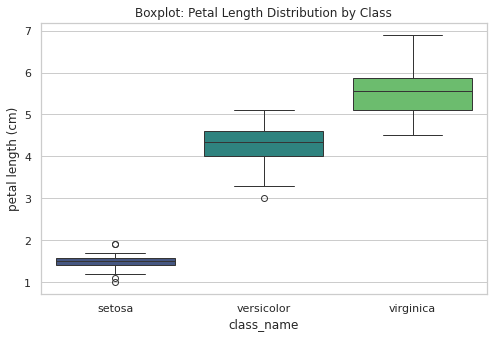

In [19]:
#19
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='class_name', y='petal length (cm)', hue='class_name', palette='viridis', legend=False)
plt.title("Boxplot: Petal Length Distribution by Class")
plt.show()

In [20]:
#20
#setosa, because it's dataset far from the other flowers dataset and the easiest to separate.

In [21]:
#21
#Petal length and Petal width are the most useful features. In the pairplot, the scatter plots using 'sepal' measurements show a lot of overlapping. However, when plotting 'petal length' against 'petal width', the three flower classes form much tighter and distinct clusters with very little overlap, making it much easier for an algorithm to draw boundaries.


PART5: PREPARE DATA FOR MACHINE LEARNING

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
#22
X = df.drop(columns=['target', 'class_name'])

In [24]:
#23
y = df['target']

In [25]:
#24 -25
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [26]:
#26
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (120, 4)
y_train shape: (120,)
X_test shape: (30, 4)
y_test shape: (30,)


In [27]:
#27
#To prevent rote memorization of the model and to truly explain the rules, you use characters to divide the data and everything at the very beginning.

PART 6: TRAIN A CLASSIFICATION MODEL

In [28]:
#28
from sklearn.tree import DecisionTreeClassifier

In [29]:
#29
clf_tree = DecisionTreeClassifier(random_state=42)

In [30]:
#30
clf_tree.fit(X_train, y_train)
print("Model training is complete!")

Model training is complete!


In [31]:
#31
y_pred = clf_tree.predict(X_test)
print("Predictions on X_test:", y_pred)
print("Actual y_test values :", y_test.values)

Predictions on X_test: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Actual y_test values : [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [32]:
#32
#I selected the Decision Tree Classifier because it is highly interpretable and works perfectly for simple classification tasks like the Iris dataset. It mimics human decision-making by splitting data based on simple feature thresholds (e.g., "Is petal length < 2.4 cm?"). It also does not require complex data scaling or normalization before training.

PART7: Evaluate the Model

In [38]:
#33
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)


1.0


In [39]:

#34
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [40]:
#35
from sklearn.metrics import classification_report
class_report = classification_report(y_test, y_pred, target_names=['setosa', 'versicolor', 'virginica'])
print(class_report)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [ ]:
#36
#The accuracy score represents the overall percentage of correct predictions made by our model. An accuracy of 1.00 (or 100%) means that the model correctly identified the flower species for all 30 samples in our hidden test set without making a single mistake.

In [42]:
#37
#Looking at the classification report, the precision, recall, and F1-scores are all perfectly 1.00 for all three classes (setosa, versicolor, and virginica). This indicates that the model has zero false positives (perfect precision) and zero false negatives (perfect recall) for every single flower type.

In [ ]:
#38
#The model did not confuse any classes. We can easily tell this because all the numbers in the confusion matrix are located strictly on the main diagonal (which represents correct predictions). All off-diagonal values are exactly 0, meaning there was absolutely no confusion between the flower types.

PART8: Visualize the Evaluation Results

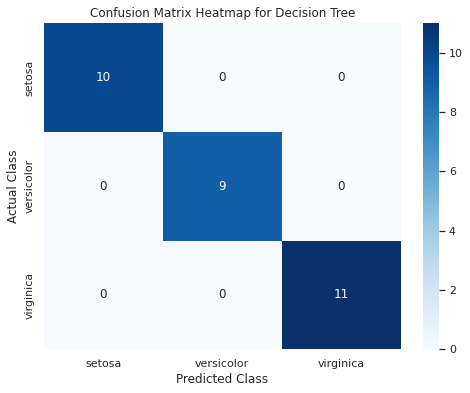

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['setosa', 'versicolor', 'virginica'], 
            yticklabels=['setosa', 'versicolor', 'virginica'])

plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix Heatmap for Decision Tree')

plt.show()

In [ ]:
#42
#The diagonal values (from top-left to bottom-right) represent the correct predictions made by the model. These are the instances where the model's predicted class perfectly matched the actual class of the flower.

In [ ]:
#43
#The off-diagonal values represent the model's errors or incorrect predictions. For example, if there was a number in the row for 'actual versicolor' but the column for 'predicted virginica', it would mean the model incorrectly confused a versicolor flower for a virginica.

In [ ]:
#44
#Based on the heatmap, the model performed exceptionally well. All of our data points are concentrated strictly on the main diagonal, and all off-diagonal values are 0. This visualizes a perfect 100% accuracy score, meaning there were zero misclassifications.

PART8: Compare Two Classification Algorithms

In [ ]:
#45 - 46
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

clf_knn = KNeighborsClassifier(n_neighbors=3)
clf_knn.fit(X_train, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [54]:
#47
y_pred_knn = clf_knn.predict(X_test)
print(y_pred_knn)

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [ ]:
#48 - 49
acc_knn = accuracy_score(y_test, y_pred_knn)
conf_knn = confusion_matrix(y_test, y_pred_knn)
print(acc_knn)
print(conf_knn)

1.0
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [ ]:
#50
#Both models performed equally well. According to our test results, both the Decision Tree and the KNN algorithm achieved a perfect accuracy score of 1.00 (100%). Their confusion matrices are exactly identical, showing zero misclassifications for both models.

In [ ]:
#51
#The Iris dataset is very small (only 150 samples) and extremely clean, meaning there are no missing values and very few outliers. More importantly, as we saw in our Part 4 visualizations (like the pairplot), the flower classes are highly separable based on petal measurements. When data is this clean and distinct, almost any basic machine learning algorithm will easily find the correct boundaries and achieve near-perfect results.


PART10 Final Interpretation

In [ ]:
#52
#when ı looked this dataset, came into various petal and sepal measuremant, there is no empty(null- NaN) deta, and  datas was balenced. 

In [ ]:
#53
#ı selected desicion tree algoritham because, this algoritham  has similar working style with human brain. also it works with more eficient Iris data set.

In [ ]:
#54
#my model had excellent performance, achieving a 100% (1.00) accuracy score on the test  when i examined the confusion matrix i saw that the numbers along the main diagonal representing correct predictions  were all 1, while all cells outside the diagonal, indicating errors, were “0.” in other words, the model did not confuse any flowers with one another.

In [ ]:
#55
#This was a small dataset. Working with big data can be challenging.

In [ ]:
#56
#this project was so interesting for me. i have never been work with data and this topic. so,  throught this project i learned various thing for example overfitting and underfitting, seaborn, pandas, deciations tree. i aware that data vitualization is enjaoyable. 